<a href="https://colab.research.google.com/github/majortank/AI-Course-2026/blob/main/Homework_One.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vaal Medical Group ML Challenge: Data Pre-processing & Predictive Modeling

## 1. Initial Setup

In [28]:
# Import core data manipulation libraries
import pandas as pd
import numpy as np
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
# Import machine ,earning and evaluation metrics from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 2. Loading Data

In [29]:
# 1. Load the dataset
df = pd.read_csv('/content/data/sa_healthcare_big_messy.csv')

## Initial Audit

### Get a quick sammary of the DataFrame

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5030 non-null   int64  
 1   sex       5030 non-null   object 
 2   bmi       4778 non-null   float64
 3   children  5030 non-null   int64  
 4   smoker    5030 non-null   object 
 5   region    5030 non-null   object 
 6   charges   5030 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 275.2+ KB


### Get statistics for numeric columns

In [31]:
df.describe()

,age,bmi,children
count,5030.000000,4778.000000,5030.000000
mean,39.500795,30.612060,1.075348
std,15.805171,6.180599,1.181521
min,-12.000000,15.960000,0.000000
25%,26.000000,26.200000,0.000000
50%,39.000000,30.250000,1.000000
75%,51.000000,34.770000,2.000000
max,140.000000,53.130000,5.000000


In [32]:
print(f"Data type of 'charges' before cleaning: {df['charges'].dtype}")
print(f"Number of missing values (NaN) in the 'bmi' column: {df['bmi'].isna().sum()}")

Data type of 'charges' before cleaning: object
Number of missing values (NaN) in the 'bmi' column: 252


## Data Engineering and Cleaning

### Depuplication

In [33]:
# See duplicates before removing them
print(df.duplicated().sum())
df[df.duplicated()]

3284


,age,sex,bmi,children,smoker,region,charges
56,31,male,39.490,1,no,KwaZulu-Natal,"R3,875.73"
74,58,male,25.175,0,no,Eastern Cape,"R11,931.13"
124,51,male,23.210,1,yes,KwaZulu-Natal,"R22,218.11"
155,64,male,26.410,0,no,Eastern Cape,"R14,394.56"
167,18,female,39.820,0,no,KwaZulu-Natal,"R1,633.96"
...,...,...,...,...,...,...,...
5025,140,female,30.210,3,no,Gauteng,"R7,537.16"
5026,19,male,20.615,2,no,Gauteng,"R2,803.70"
5027,32,female,20.520,0,no,Eastern Cape,"R4,544.23"
5028,62,female,39.200,0,no,Western Cape,"R13,470.86"


In [34]:
initial_row_count = len(df)

In [35]:
df = df.drop_duplicates()

In [36]:
duplicates_removed = initial_row_count - len(df)

In [37]:
print(f"1. Total number of duplicates rows  removed: {duplicates_removed}")

1. Total number of duplicates rows  removed: 3284


In [38]:
print(df.duplicated().sum())

0


### String Harmonization (Regions, Sex, Smoker)

#### Find variations of "Gauteng" before cleaning to answer Section 6.2.2

In [39]:
gauteng_variations = [region for region in df['region'].dropna().unique() if 'gauteng' in str(region).lower()]
print(f"2. Variations of 'Gauteng' found: {gauteng_variations}")

2. Variations of 'Gauteng' found: ['GAUTENG', 'Gauteng', 'gauteng']


### Clean string columns by stripping whitespace and standardizing case

In [40]:
df['region'] = df['region'].str.strip().str.title()
df['sex'] = df['sex'].str.strip().str.title()
df['smoker'] = df['smoker'].str.strip().str.title()

### Type Casting ('charges')

In [41]:
# Remove 'R' symbol and commas, then convert the remaining to a float
df['charges'] = df['charges'].str.replace('R', '', regex=False).str.replace(',', '', regex=False).astype(float)

### Biological Validation (Biological Impossibilities)

In [42]:
# Filter out rows where age is less than 0 or greater than 100
age_outliers_mask = (df['age'] < 0) | (df['age'] > 100)
age_outliers_count = age_outliers_mask.sum()
# Keep only valid ages
df = df[~age_outliers_mask]
print(f"3. Number of age-related outliers removed (<0 or >100): {age_outliers_count}")
print(f"4. Final row count remaining for model training: {len(df)}")


3. Number of age-related outliers removed (<0 or >100): 50
4. Final row count remaining for model training: 1696


### Smart Imputation

In [43]:
# Impute missing BMI values with the median BMI of the dataset
# why Median
# 1. Using mean might give a value too high or too low if there are extreme BMI values
#. Using median ensures that the imputed value is typical of the dataset, not distorted by outliers.

In [44]:
bmi_median = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)

### Categorical Encoding (One-Hot Encoding)

In [45]:
# Transform non-numeric features (sex, smoker, and region) into a format suitable for regression
# drop_first=True helps avoid the "dummy variable trap" (multicollinearity)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

print(f"5. Final row count remaining for model training: {len(df_encoded)}")
print("\nFirst 3 rows of the fully cleaned and encoded dataset:")
display(df_encoded.head(3))

5. Final row count remaining for model training: 1696

First 3 rows of the fully cleaned and encoded dataset:


,age,bmi,children,charges,sex_Male,smoker_Yes,region_Gauteng,region_Kwazulu-Natal,region_Western Cape
0,55,29.900,0,10214.64,True,False,False,False,True
1,37,47.600,2,46113.51,False,True,False,False,True
2,58,25.175,0,11931.13,True,False,False,False,False


## Exploratory Data Analysis (EDA)

### Distribution of Medical Spend (Histogram)

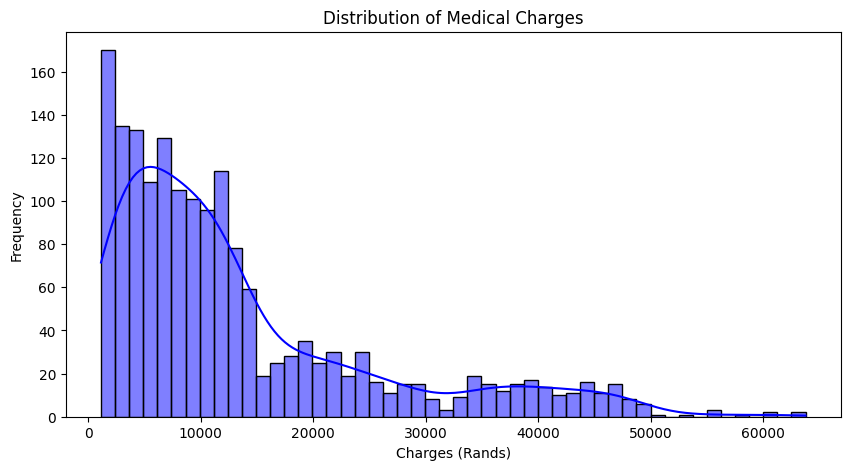

In [46]:
# 1. Distribution of Medical Spend (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='blue', bins=50)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges (Rands)")
plt.ylabel("Frequency")
plt.show()
# Logic Insight: Observe if the tail pulls to the right (Right-Skewed) or looks like a bell curve (Normal).

### Medical Expenditure by Province (Boxplot)

/tmp/ipykernel_1243/3127541699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='charges', data=df, palette='Set2')


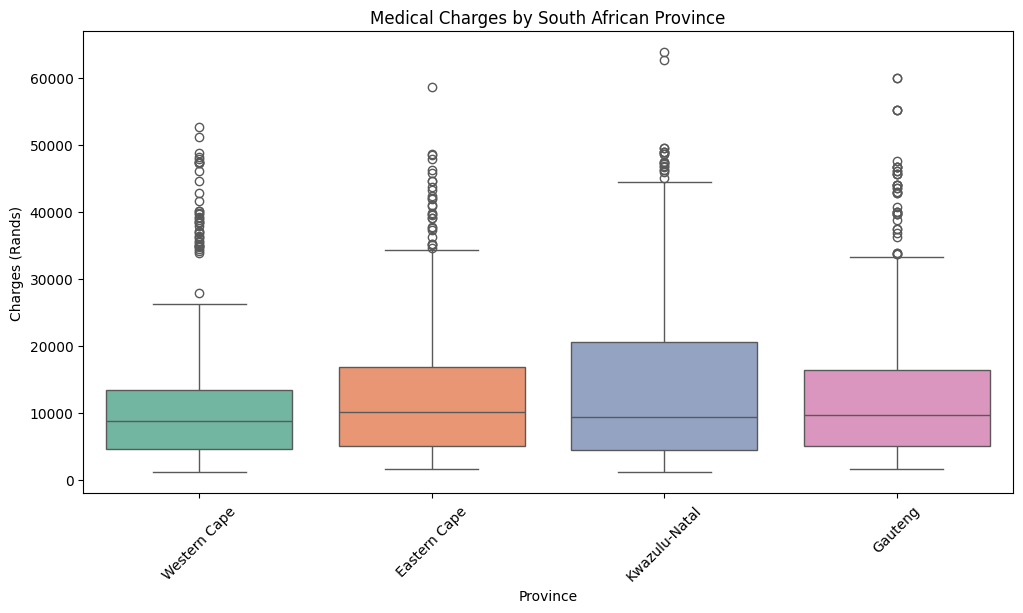

In [47]:
# 2. Medical Expenditure by Province (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='charges', data=df, palette='Set2')
plt.title("Medical Charges by South African Province")
plt.xlabel("Province")
plt.ylabel("Charges (Rands)")
plt.xticks(rotation=45)
plt.show()
# Logic Insight: Look for the boxplot with the highest horizontal line inside the box (the median).

### Correlation Analysis (Heatmap)

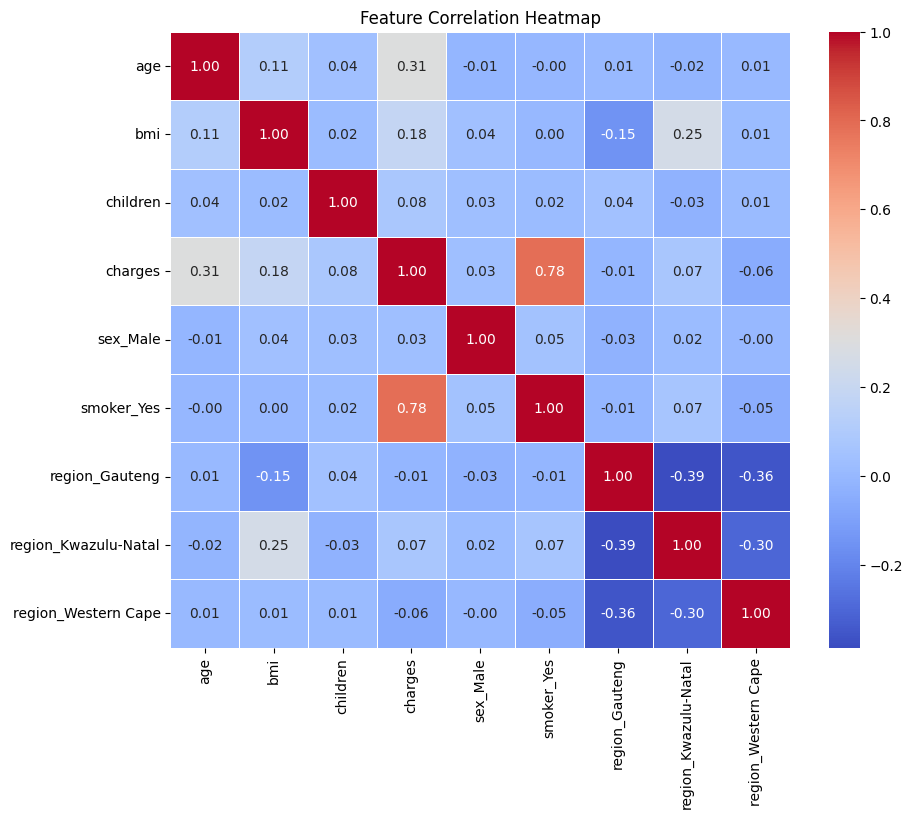

In [48]:
# 3. Correlation Analysis (Heatmap)
plt.figure(figsize=(10, 8))
# Calculate the correlation matrix and plot it
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
# Logic Insight: Find the row/column for 'charges'. Look for the highest positive number (closest to 1.0) ignoring 'charges' itself.

### Interaction Analysis Scatter Plot

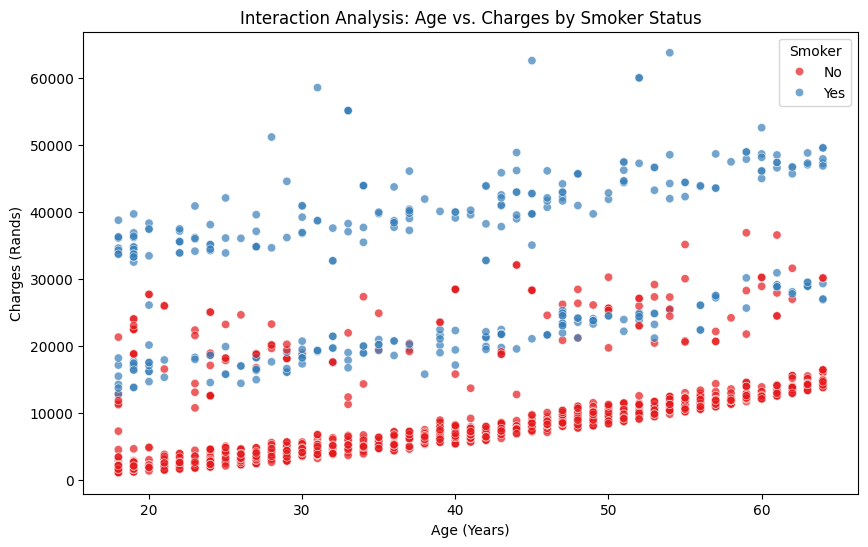

In [49]:
# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('Interaction Analysis: Age vs. Charges by Smoker Status')
plt.xlabel('Age (Years)')
plt.ylabel('Charges (Rands)')
plt.legend(title='Smoker')

## MACHINE LEARNING MODELING

### Algorithm Comparison

#### LinearRegression

Algorithm Used: Linear Regression
R2 Score: 0.7483
Calculated RMSE: R6292.04


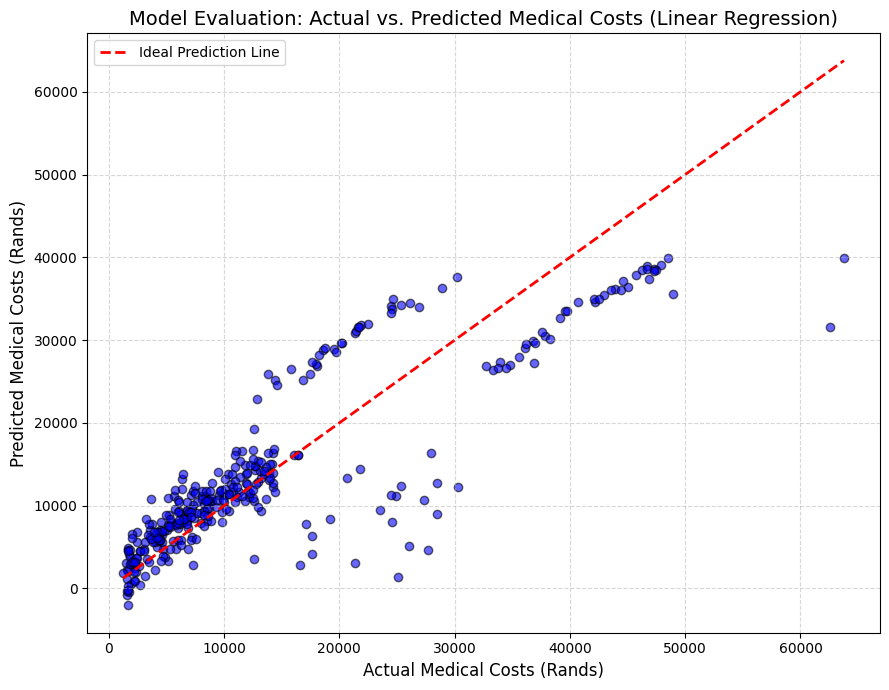

In [54]:
# Step 1: Define Features (X) and Target Variable (y)
# We use df_encoded because the model requires all inputs to be numeric
X = df_encoded.drop('charges', axis=1)  # All columns except 'charges' are our features
y = df_encoded['charges']               # 'charges' is what we are trying to predict

# Step 2: Split the dataset into Training and Testing sets
# 80% of the data is used to train the model, 20% is held back to test its accuracy
# random_state=42 ensures we get the exact same split (and same results) every time we run the cell
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and Train the Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train) # The model learns the relationships in the training data

# Step 4: Make Predictions
# We ask the trained model to predict charges for our unseen test data
lr_predictions = lr_model.predict(X_test)

# Step 5: Evaluate Model Performance
# R2 Score: Measures how well the variance in the features explains the variance in the target (closer to 1.0 is better)
lr_r2 = r2_score(y_test, lr_predictions)

# RMSE: Measures the average error of the predictions in the original units (Rands)
# We calculate Mean Squared Error first, then take the square root (np.sqrt)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

# Output the metrics for Section 6.3 of the Answer Sheet
print(f"Algorithm Used: Linear Regression")
print(f"R2 Score: {lr_r2:.4f}")
print(f"Calculated RMSE: R{lr_rmse:.2f}")

# Plot Actual vs Predicted for Linear Regression
plt.figure(figsize=(9, 7))
plt.scatter(y_test, lr_predictions, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction Line')
plt.title('Model Evaluation: Actual vs. Predicted Medical Costs (Linear Regression)', fontsize=14)
plt.xlabel('Actual Medical Costs (Rands)', fontsize=12)
plt.ylabel('Predicted Medical Costs (Rands)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()


### RANDOM FOREST REGRESSOR

Algorithm Used: Random Forest Regressor
R2 Score: 0.8310
Calculated RMSE: R5156.13


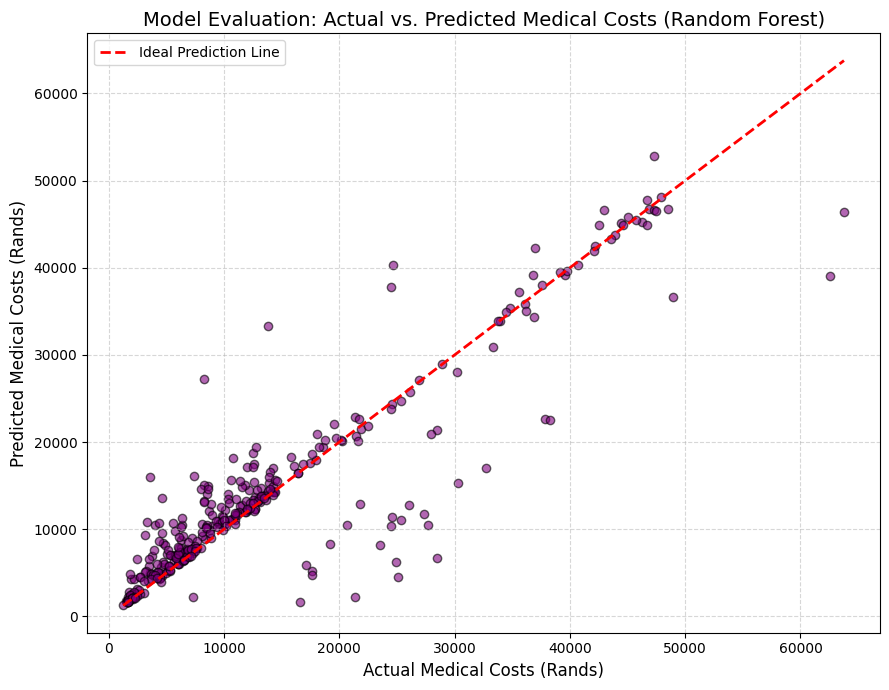

In [53]:
# Step 1: Initialize the Model
# n_estimators=100 means the model will build 100 individual decision trees
# random_state=42 ensures our results are reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Step 2: Train the Model
# We fit the Random Forest to the exact same training data (X_train, y_train) used for Linear Regression
rf_model.fit(X_train, y_train)

# Step 3: Make Predictions
# The model uses the 100 trees to estimate charges for the unseen test data
rf_predictions = rf_model.predict(X_test)

# Step 4: Evaluate Model Performance
rf_r2 = r2_score(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

# Output the metrics for Section 6.3 of the Answer Sheet
print(f"Algorithm Used: Random Forest Regressor")
print(f"R2 Score: {rf_r2:.4f}")
print(f"Calculated RMSE: R{rf_rmse:.2f}")

# --- 5. ACTUAL VS PREDICTED VISUALIZATION ---

# Plotting the results of our best-performing model (Random Forest)
plt.figure(figsize=(9, 7))

# Create a scatter plot of the actual charges vs. the model's predicted charges
plt.scatter(y_test, rf_predictions, alpha=0.6, color='purple', edgecolors='k')

# Draw the "Ideal" line (where Actual equals Predicted perfectly)
# We plot a diagonal red dashed line from the minimum to maximum test values
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction Line')

# Add professional titles and labels
plt.title("Model Evaluation: Actual vs. Predicted Medical Costs (Random Forest)", fontsize=14)
plt.xlabel("Actual Medical Costs (Rands)", fontsize=12)
plt.ylabel("Predicted Medical Costs (Rands)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()

# Logic Insight for Answer Sheet (Section 6.4.4):
# Look at how the purple dots cluster around the red dashed line.
# At lower costs, they stay very tight to the line (high accuracy).
# As costs increase (move further to the right), the points spread out more (fan shape).
# This means the model is highly accurate for lower medical bills but slightly less precise for extreme, high-cost cases.